# SAM3 Image Detection

This notebook demonstrates how to use FilterSAM3Detector to detect objects in an image.


In [34]:
import cv2
import numpy as np
from pathlib import Path
from openfilter.filter_runtime.filter import Frame
from filter_sam3_detector.filter import FilterSAM3Detector
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


## Configuration

Configure the image path and detection prompt:


In [35]:
# Configuration
image_path = Path("imgs_demo/salad2.png")  # Change to your image path
confidence_threshold = 0.2  # Minimum confidence threshold for SAM3 detector
min_score_filter = 0.4  # Minimum score to keep in final results (filters out low-confidence detections)

# Define objects to detect (each will be processed separately to get labeled bounding boxes)
# objects_to_detect = ["avocado", "tomato", "cucumber"]  # List of objects to detect
objects_to_detect = ["pomegranate", "carrots"]  # List of objects to detect

# Note: Processing each object separately ensures we get labeled bounding boxes
# for each type (avocado vs tomato)

print(min_score_filter, confidence_threshold)

0.4 0.2


## Load Image


Image loaded: salad2.png
Dimensions: 2972x1720


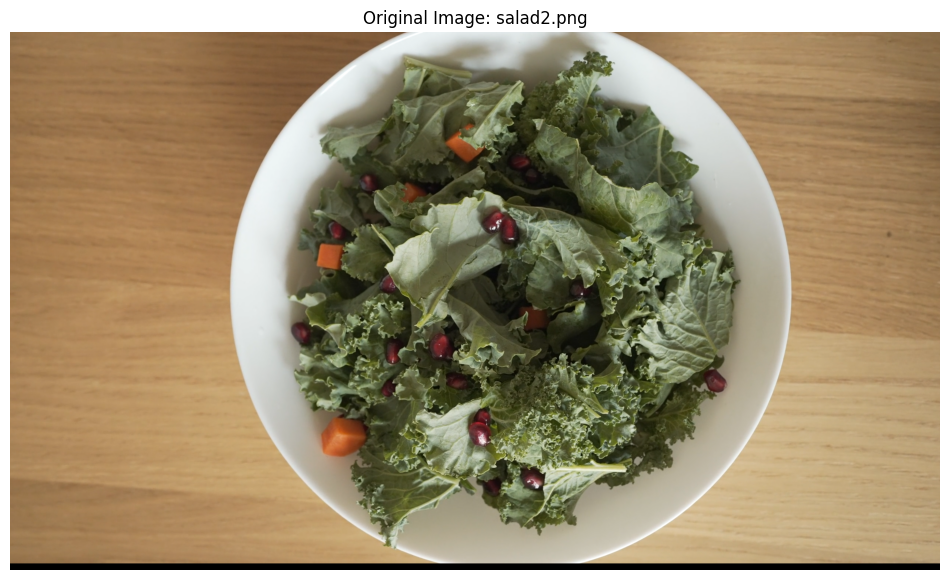

In [36]:
# Load image
img_bgr = cv2.imread(str(image_path))
if img_bgr is None:
    raise ValueError(f"Could not load image: {image_path}")

# Convert BGR to RGB for visualization
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f"Image loaded: {image_path.name}")
print(f"Dimensions: {img_bgr.shape[1]}x{img_bgr.shape[0]}")

# Visualize original image
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title(f"Original Image: {image_path.name}")
plt.show()


## Initialize SAM3 Detector

We'll process each object type separately to get labeled bounding boxes.


In [28]:
# Initialize detector (we'll change the prompt for each object)
detector = FilterSAM3Detector({
    "text_prompt": objects_to_detect[0],  # Will be updated for each object
    "confidence_threshold": confidence_threshold,
    "device": "cuda",  # or "cpu" if no GPU
    "visualize": False,
    "output_label": "detections",
})

detector.setup(detector.config)
print("SAM3 Detector initialized successfully!")


2025-12-19 08:35:24.992 1795653 INFO     [Filter] Raw subject data export is DISABLED (set OPENLINEAGE_EXPORT_RAW_DATA=true to enable)
2025-12-19 08:35:24.998 1795653 INFO     FilterSAM3Detector(config={'text_prompt': 'pomegranate', 'confidence_threshold': 0.2, 'device': 'cuda', 'visualize': False, 'output_label': 'detections', 'id': 'FilterSAM3Detector-mvrGxa'})
2025-12-19 08:35:25.021 1795653 INFO     ==========================================
2025-12-19 08:35:25.025 1795653 INFO     FilterSAM3Detector setup: {'text_prompt': 'pomegranate', 'confidence_threshold': 0.2, 'device': 'cuda', 'visualize': False, 'output_label': 'detections', 'id': 'FilterSAM3Detector-mvrGxa'}
2025-12-19 08:35:25.027 1795653 INFO     ==========================================
2025-12-19 08:35:25.029 1795653 INFO     Using device: cuda
2025-12-19 08:35:25.030 1795653 INFO     Loading SAM3 model on device: cuda
2025-12-19 08:35:25.031 1795653 INFO     Found BPE file at: /home/leandrobmarinho/datasets/filter-sa

SAM3 Detector initialized successfully!


## Process Image for Each Object Type


In [29]:
# Process each object type separately to get labeled bounding boxes
all_detections = []  # List of detections with labels: [{"label": "avocado", "box": [...], "score": ...}, ...]

print("Processing image for each object type...")
for obj_label in objects_to_detect:
    print(f"\nDetecting: {obj_label}")
    
    # Update detector prompt for this object
    detector.cfg.text_prompt = obj_label
    detector.text_prompt = obj_label
    
    # Create Frame object
    frame = Frame(image=img_bgr, format="BGR")
    frames_dict = {"frames": frame}
    
    # Run detection
    detected = detector.process(frames_dict)
    
    # Extract detections and label them
    if detected:
        for topic, frame in detected.items():
            dets = frame.data.get('meta', {}).get('detections', [])
            for det in dets:
                # Add label to each detection
                labeled_det = det.copy()
                labeled_det['label'] = obj_label
                all_detections.append(labeled_det)
            break
    
    print(f"  Found {len([d for d in all_detections if d.get('label') == obj_label])} {obj_label}(s)")

print(f"\nTotal detections before filtering: {len(all_detections)}")

# Filter detections by minimum score
original_count = len(all_detections)
filtered_detections = [det for det in all_detections if det.get('score', 0.0) >= min_score_filter]
all_detections = filtered_detections
removed_count = original_count - len(all_detections)

print(f"Total detections after filtering (score >= {min_score_filter}): {len(all_detections)}")
if removed_count > 0:
    print(f"Removed {removed_count} detections with score < {min_score_filter}")


Processing image for each object type...

Detecting: pomegranate
  Found 24 pomegranate(s)

Detecting: carrots
  Found 6 carrots(s)

Total detections before filtering: 30
Total detections after filtering (score >= 0.4): 24
Removed 6 detections with score < 0.4


## Display Detections


In [30]:
# Display detection information
print(f"Number of detections found: {len(all_detections)}")

# Group by label
detections_by_label = {}
for det in all_detections:
    label = det.get('label', 'unknown')
    if label not in detections_by_label:
        detections_by_label[label] = []
    detections_by_label[label].append(det)

# Display summary
print("\nSummary by object type:")
for label, dets in detections_by_label.items():
    print(f"  {label}: {len(dets)} detection(s)")

# Display detailed information
print("\nDetailed detections:")
for i, det in enumerate(all_detections, 1):
    label = det.get('label', 'unknown')
    box = det.get('box', [])
    score = det.get('score', 0.0)
    print(f"\nDetection {i} ({label}):")
    print(f"  Score: {score:.3f}")
    print(f"  Bounding Box: {box}")
    if len(box) == 4:
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1
        print(f"  Position: ({x1}, {y1})")
        print(f"  Size: {width}x{height}")


Number of detections found: 24

Summary by object type:
  pomegranate: 19 detection(s)
  carrots: 5 detection(s)

Detailed detections:

Detection 1 (pomegranate):
  Score: 0.712
  Bounding Box: [1179, 776, 1237, 837]
  Position: (1179, 776)
  Size: 58x61

Detection 2 (pomegranate):
  Score: 0.710
  Bounding Box: [1114, 454, 1176, 515]
  Position: (1114, 454)
  Size: 62x61

Detection 3 (pomegranate):
  Score: 0.712
  Bounding Box: [1392, 1088, 1466, 1145]
  Position: (1392, 1088)
  Size: 74x57

Detection 4 (pomegranate):
  Score: 0.713
  Bounding Box: [1563, 589, 1625, 681]
  Position: (1563, 589)
  Size: 62x92

Detection 5 (pomegranate):
  Score: 0.468
  Bounding Box: [1323, 483, 1384, 520]
  Position: (1323, 483)
  Size: 61x37

Detection 6 (pomegranate):
  Score: 0.727
  Bounding Box: [1631, 1392, 1708, 1464]
  Position: (1631, 1392)
  Size: 77x72

Detection 7 (pomegranate):
  Score: 0.736
  Bounding Box: [2216, 1077, 2291, 1153]
  Position: (2216, 1077)
  Size: 75x76

Detection 8 (po

## Visualize Results


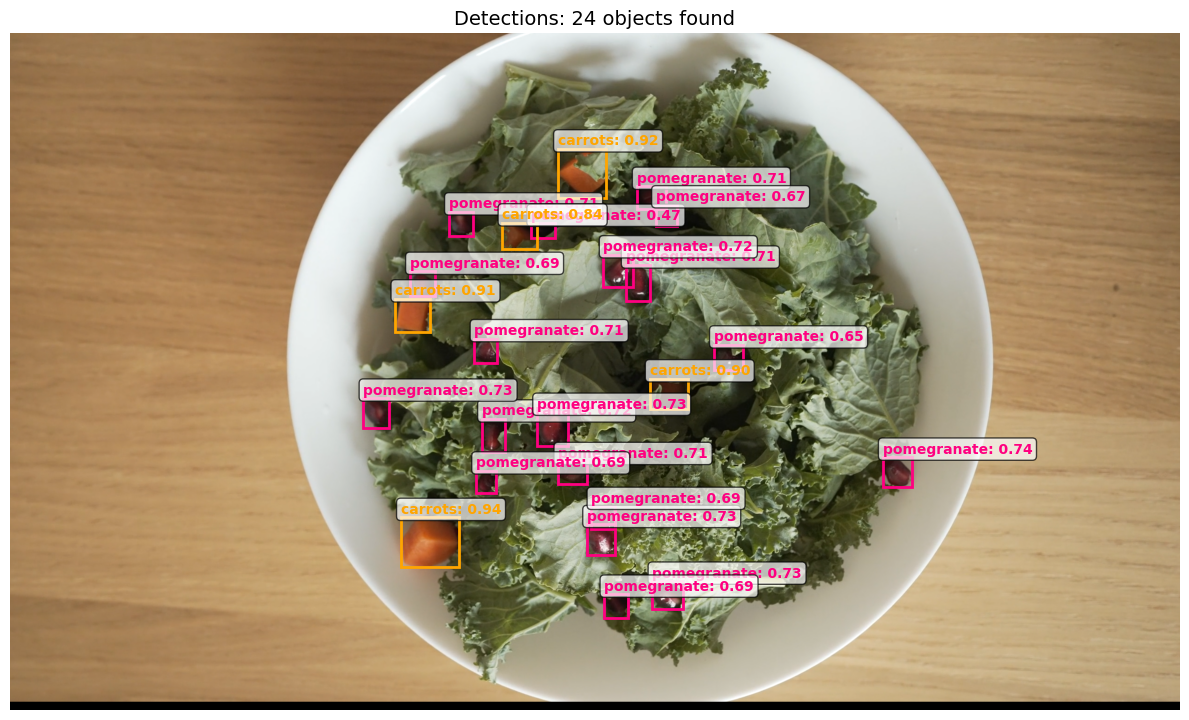

In [31]:
# Visualize image with detections (color-coded by object type)
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(img_rgb)
ax.axis('off')
ax.set_title(f"Detections: {len(all_detections)} objects found", fontsize=14)

# Color map for different object types
label_colors = {
    "avocado": (0, 255, 0),      # Green
    "tomato": (255, 0, 0),       # Red
    "cucumber": (0, 255, 255),   # Cyan
    "cup": (0, 0, 255),          # Blue
    "pomegranate": (255, 0, 128), # Pink/Magenta
    "carrots": (255, 165, 0),    # Orange
}
default_color = (255, 255, 0)    # Yellow for unknown

# Draw bounding boxes with labels
for det in all_detections:
    label = det.get('label', 'unknown')
    box = det.get('box', [])
    score = det.get('score', 0.0)
    
    if len(box) == 4:
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1
        
        # Get color for this label
        color_rgb = label_colors.get(label.lower(), default_color)
        color_normalized = tuple(c/255.0 for c in color_rgb)
        
        # Draw rectangle
        rect = Rectangle((x1, y1), width, height, 
                        linewidth=2, edgecolor=color_normalized, 
                        facecolor='none')
        ax.add_patch(rect)
        
        # Add label with object type and score
        label_text = f"{label}: {score:.2f}"
        ax.text(x1, y1 - 10, label_text, 
               color=color_normalized, fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()


## Save Results


In [32]:
import json

# Prepare data to save (with labels)
h, w = img_bgr.shape[:2]
results = {
    "image_path": str(image_path),
    "image_name": image_path.name,
    "width": w,
    "height": h,
    "objects_detected": objects_to_detect,
    "detections": [
        {
            "label": d.get('label', 'unknown'),
            "box": d['box'],
            "score": float(d['score'])
        } 
        for d in all_detections
    ]
}

# Save JSON
output_json = image_path.parent / f"{image_path.stem}_detections.json"
with open(output_json, 'w') as f:
    json.dump(results, f, indent=2)

print(f"Results saved to: {output_json}")

# Save image with detections (color-coded by label)
if len(all_detections) > 0:
    # Create copy of image to draw on
    img_with_detections = img_rgb.copy()
    
    # Color map for different object types
    label_colors_bgr = {
        "avocado": (0, 255, 0),      # Green in BGR
        "tomato": (0, 0, 255),      # Red in BGR
        "cup": (255, 0, 0),         # Blue in BGR
    }
    default_color_bgr = (0, 255, 255)  # Yellow for unknown
    
    # Draw bounding boxes with labels
    for det in all_detections:
        label = det.get('label', 'unknown')
        box = det.get('box', [])
        score = det.get('score', 0.0)
        
        if len(box) == 4:
            x1, y1, x2, y2 = box
            color = label_colors_bgr.get(label.lower(), default_color_bgr)
            
            # Draw rectangle
            cv2.rectangle(img_with_detections, (x1, y1), (x2, y2), color, 2)
            
            # Add label with object type and score
            label_text = f"{label}: {score:.2f}"
            cv2.putText(img_with_detections, label_text, (x1, y1 - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    # Convert RGB to BGR to save with OpenCV
    img_bgr_output = cv2.cvtColor(img_with_detections, cv2.COLOR_RGB2BGR)
    output_image = image_path.parent / f"{image_path.stem}_detections.jpg"
    cv2.imwrite(str(output_image), img_bgr_output)
    print(f"Image with detections saved to: {output_image}")


Results saved to: imgs_demo/salad2_detections.json
Image with detections saved to: imgs_demo/salad2_detections.jpg


## Cleanup Resources


In [33]:
# Close detector
detector.shutdown()
print("Detector closed.")


2025-12-19 08:35:45.427 1795653 INFO     FilterSAM3Detector shutdown
2025-12-19 08:35:45.586 1795653 INFO     FilterSAM3Detector shutdown complete


Detector closed.


---

## Image 2: Salad 2

Processing second image with different ingredients.


## Configuration for Image 2


In [1]:
# Configuration for Image 2
image_path_2 = Path("imgs_demo/salad2.png")  # Second image
confidence_threshold_2 = 0.2  # Same as image 1
min_score_filter_2 = 0.7  # Same as image 1

# Define objects to detect for image 2 (different ingredients)
objects_to_detect_2 = ["pomegranate", "carrots"]  # List of objects to detect

print(f"Image 2: {image_path_2.name}")
print(f"Objects: {objects_to_detect_2}")
print(f"Confidence threshold: {confidence_threshold_2}")
print(f"Min score filter: {min_score_filter_2}")


NameError: name 'Path' is not defined

## Load Image 2


In [4]:
# Load image 2
img_bgr_2 = cv2.imread(str(image_path_2))
if img_bgr_2 is None:
    raise ValueError(f"Could not load image: {image_path_2}")

# Convert BGR to RGB for visualization
img_rgb_2 = cv2.cvtColor(img_bgr_2, cv2.COLOR_BGR2RGB)

print(f"Image loaded: {image_path_2.name}")
print(f"Dimensions: {img_bgr_2.shape[1]}x{img_bgr_2.shape[0]}")

# Visualize original image
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb_2)
plt.axis('off')
plt.title(f"Original Image: {image_path_2.name}")
plt.show()


NameError: name 'image_path_2' is not defined

## Process Image 2 for Each Object Type


In [ ]:
# Process each object type separately to get labeled bounding boxes
all_detections_2 = []  # List of detections with labels

print("Processing image 2 for each object type...")
for obj_label in objects_to_detect_2:
    print(f"\nDetecting: {obj_label}")
    
    # Update detector prompt for this object
    detector.cfg.text_prompt = obj_label
    detector.text_prompt = obj_label
    
    # Create Frame object
    frame = Frame(image=img_bgr_2, format="BGR")
    frames_dict = {"frames": frame}
    
    # Run detection
    detected = detector.process(frames_dict)
    
    # Extract detections and label them
    if detected:
        for topic, frame in detected.items():
            dets = frame.data.get('meta', {}).get('detections', [])
            for det in dets:
                # Add label to each detection
                labeled_det = det.copy()
                labeled_det['label'] = obj_label
                all_detections_2.append(labeled_det)
            break
    
    print(f"  Found {len([d for d in all_detections_2 if d.get('label') == obj_label])} {obj_label}(s)")

print(f"\nTotal detections before filtering: {len(all_detections_2)}")

# Filter detections by minimum score
original_count_2 = len(all_detections_2)
filtered_detections_2 = [det for det in all_detections_2 if det.get('score', 0.0) >= min_score_filter_2]
all_detections_2 = filtered_detections_2
removed_count_2 = original_count_2 - len(all_detections_2)

print(f"Total detections after filtering (score >= {min_score_filter_2}): {len(all_detections_2)}")
if removed_count_2 > 0:
    print(f"Removed {removed_count_2} detections with score < {min_score_filter_2}")


## Display Detections for Image 2
